In [ ]:
from matplotlib import pyplot as plt
from DiverTI.utils import *
from DiverTI.genenet import obtain_genenet
from DiverTI.train import *
import torch
import scanpy as sc
import warnings
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, adjusted_mutual_info_score
import pandas as pd
import os
import sklearn.neighbors
os.environ['R_HOME'] = 'D:\\R-4.5.0' 
warnings.filterwarnings('ignore')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
seed_all(2023)
from pathlib import Path



In [ ]:
def obtain_cellnet(adata, k_cutoff=6, use_pca=True, pca_dim=50, prune=True):
    if use_pca:
        if 'X_pca' not in adata.obsm:
            sc.pp.pca(adata, n_comps=pca_dim)
        coords = adata.obsm['X_pca']
    else:
        coords = adata.obsm.get('spatial', None)
        if coords is None:
            raise ValueError("No spatial coordinates and PCA not enabled, cannot build network.")

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k_cutoff + 1, n_jobs=-1)
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    if prune:
        non_zero_mask = distances > 0
        non_zero_distances = np.where(non_zero_mask, distances, np.nan)
        means = np.nanmean(non_zero_distances, axis=1, keepdims=True)
        stds = np.nanstd(non_zero_distances, axis=1, keepdims=True)
        boundaries = means + stds
        mask = distances > boundaries
        distances[mask] = 0

    cell_indices = np.repeat(np.arange(len(coords)), np.fromiter((len(idx) for idx in indices), dtype=int))
    neighbor_indices = np.concatenate(indices)
    neighbor_distances = np.concatenate(distances)
    cell_net_df = pd.DataFrame({
        'Cell1_idx': cell_indices,
        'Cell2_idx': neighbor_indices,
        'Distance': neighbor_distances
    })
    cell_net_df = cell_net_df[cell_net_df['Distance'] > 0]  

    cell_adj = csr_matrix(
        (cell_net_df['Distance'].values > 0, 
         (cell_net_df['Cell1_idx'], cell_net_df['Cell2_idx'])),
        shape=(adata.n_obs, adata.n_obs)
    ) 

    adata.obsp['cellnet_adj'] = cell_adj 

    id_cell_trans = dict(zip(range(len(coords)), adata.obs.index))
    cell_net_df['Cell1'] = cell_net_df['Cell1_idx'].map(id_cell_trans)
    cell_net_df['Cell2'] = cell_net_df['Cell2_idx'].map(id_cell_trans)
    adata.uns['cellnet'] = cell_net_df[['Cell1', 'Cell2', 'Distance']]
    
    return adata

In [ ]:
adata = sc.read_h5ad('F:/DiverTI/simulated data/scdata/linear1/52119215_data.h5ad')  
print("Single-cell data basic information:")
print(f"Number of cells: {adata.n_obs}, Number of genes: {adata.n_vars}")

单细胞数据基本信息:
细胞数: 1000, 基因数: 1019


In [ ]:
adata.var_names_make_unique()
prefilter_genes(adata, min_cells=3)

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=900,
    flavor="seurat", 
    inplace=True 
)
adata_hvg = adata[:, adata.var['highly_variable']].copy()

In [ ]:
adata_hvg.write_h5ad("adata_linear1_hvg_processed.h5ad")

In [ ]:
obtain_cellnet(adata_hvg, k_cutoff=6, use_pca=True, pca_dim=50)

  File "d:\anaconda\envs\DeepGFT\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


AnnData object with n_obs × n_vars = 1000 × 900
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'end_id', 'milestone_network', 'milestone_percentages', 'start_id', 'timecourse', 'hvg', 'pca', 'cellnet'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'cellnet_adj'

In [ ]:
obtain_genenet(adata_hvg)

gene edges 2036 spots 1000


In [ ]:
adata_hvg.uns['spotnet_adj'] = adata_hvg.obsp['cellnet_adj'].toarray()  
adata_hvg.uns['spotnet'] = adata_hvg.uns['cellnet'] 
print("Copied cell network to spotnet_adj for f2s_gene function compatibility.")

obtain_genenet(adata_hvg)
gene_freq_mtx, gene_eigvecs_T, gene_eigvals = f2s_gene(adata_hvg, gene_signal=1500, c1=0.05)
spot_freq_mtx, spot_eigvecs_T, spot_eigvals = f2s_spot(adata_hvg,spot_signal=1500, middle=3, c2=0.005)

已将细胞网络复制为 spotnet_adj，适配 f2s_gene 函数
gene edges 2036 spots 1000


In [ ]:
res, lamda, emb_spot, _, attention = train_spot(
    adata_hvg, gene_freq_mtx, gene_eigvecs_T, spot_freq_mtx, spot_eigvecs_T,
    alpha=7, device=device, epoch_max=200, cluster=False
)

spot*signal train


100%|██████████| 200/200 [00:04<00:00, 40.94it/s]


In [ ]:
adata_hvg.obsm['emb'] = emb_spot
sc.pp.neighbors(adata_hvg, use_rep='emb')

cluster_num = 4 
adata_hvg= mclust_R(adata_hvg , used_obsm='emb', num_cluster=cluster_num)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


fitting ...
  |======================================================================| 100%


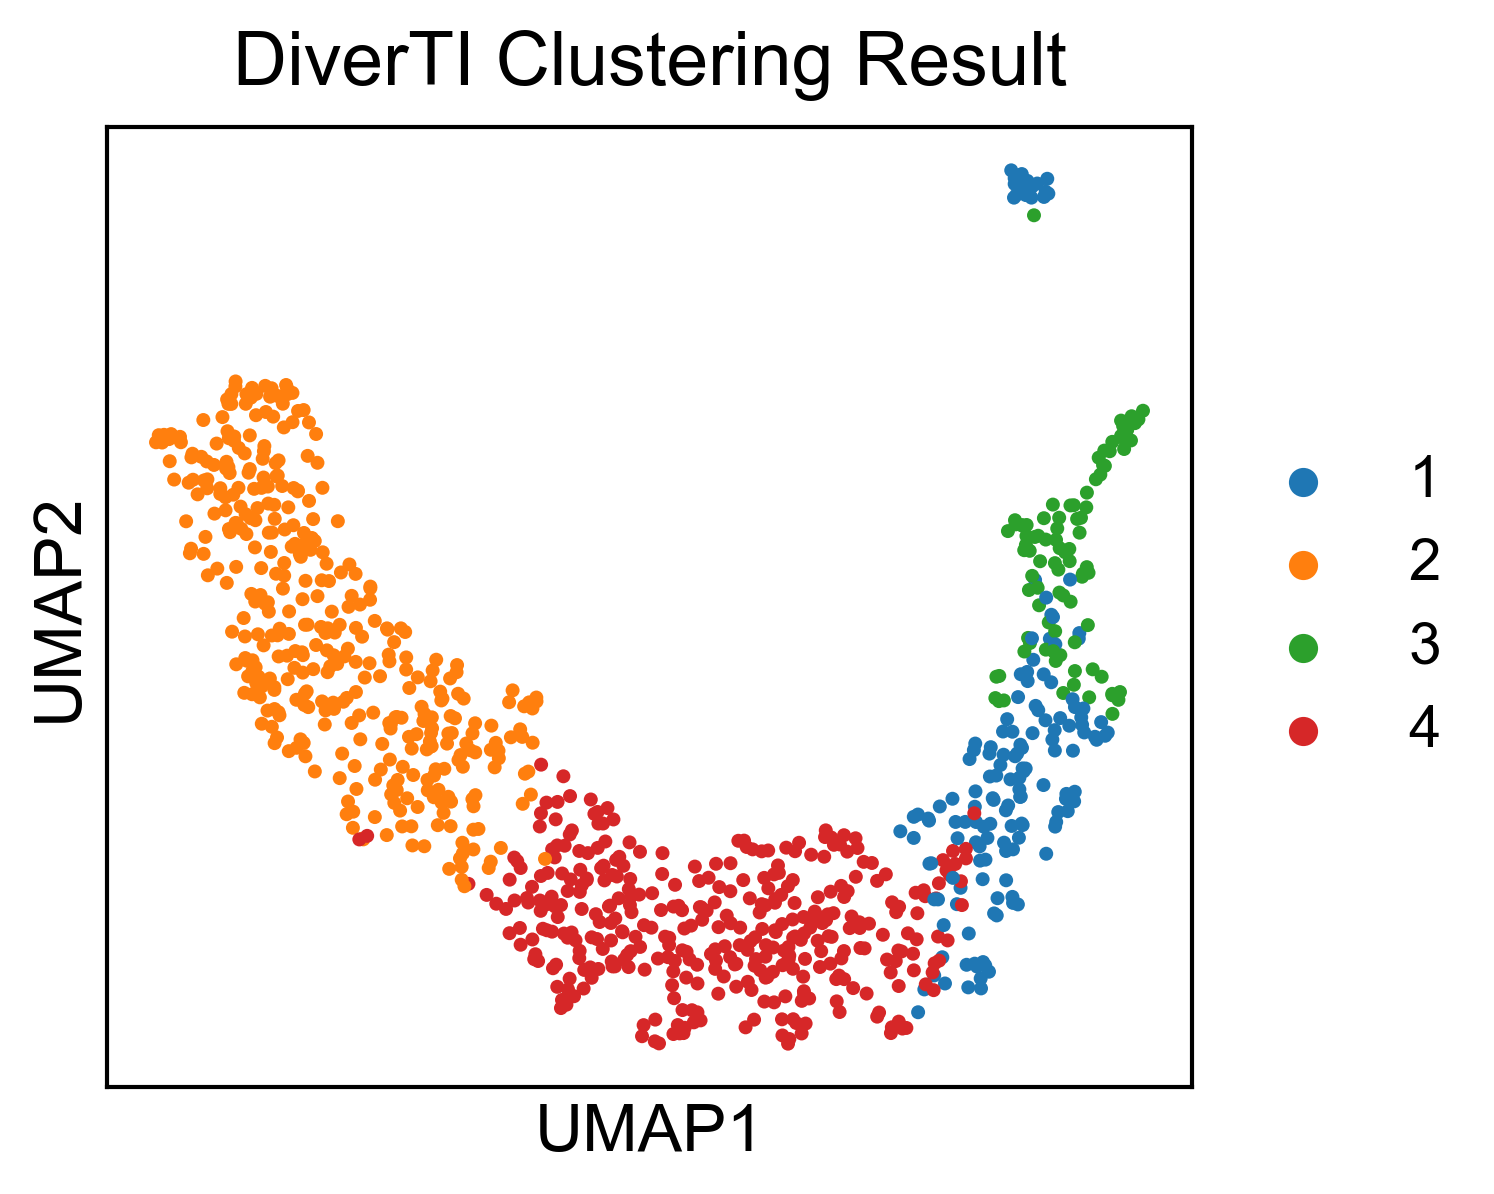

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,             
    'axes.titlesize': 18,        
    'axes.labelsize': 16,         
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14,  
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'lines.linewidth': 1,
})

adata_hvg.obsm['emb'] = emb_spot
sc.pp.neighbors(adata_hvg, use_rep='emb')
cluster_num = 4
adata_hvg = mclust_R(adata_hvg, used_obsm='emb', num_cluster=cluster_num)

sc.tl.umap(adata_hvg)

fig, ax = plt.subplots(figsize=(5.2, 4.2)) 

sc.pl.umap(
    adata_hvg,
    color='mclust',
    title='DiverTI Clustering Result',
    ax=ax,
    show=False,
    size=45,          
    legend_loc='right margin'
)

ax.set_title('DiverTI Clustering Result', fontsize=18, fontweight='normal', pad=10)
ax.set_xlabel('UMAP1', fontsize=16)
ax.set_ylabel('UMAP2', fontsize=16)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

fitting ...
  |======================================================================| 100%


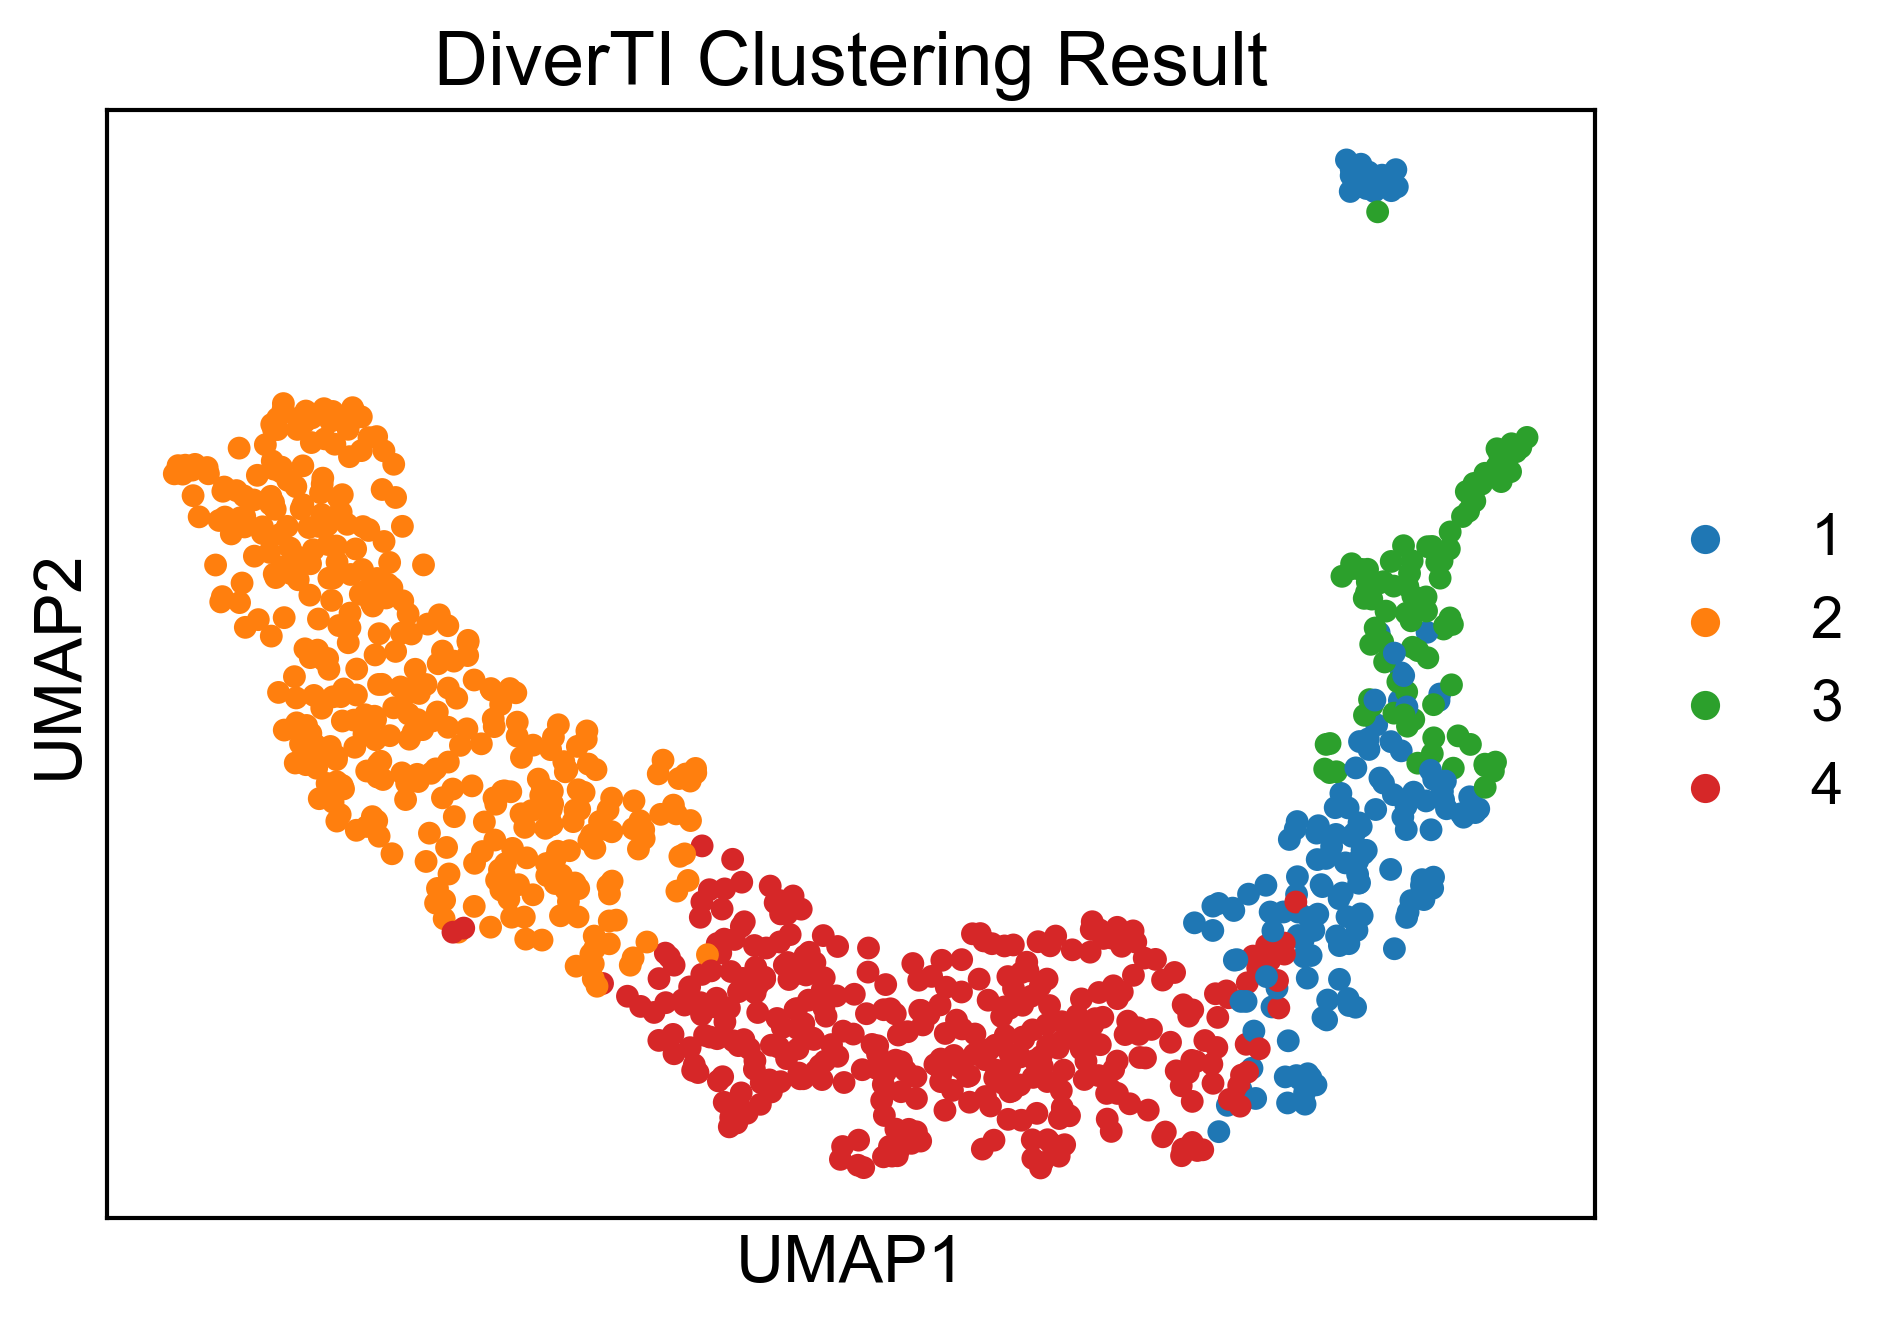

In [ ]:
adata_hvg.obsm['emb'] = emb_spot
sc.pp.neighbors(adata_hvg, use_rep='emb')
cluster_num = 4 
adata_hvg = mclust_R(adata_hvg, used_obsm='emb', num_cluster=cluster_num)

sc.tl.umap(adata_hvg)
sc.pl.umap(adata_hvg, color=['mclust'], title=['DiverTI Clustering Result'])

In [ ]:
import pandas as pd

milestone_long = adata_hvg.uns['milestone_percentages']
print(milestone_long.head())

milestone_wide = milestone_long.pivot(
    index='cell_id',     
    columns='milestone_id',
    values='percentage'   
).reset_index()

milestone_wide = milestone_wide.set_index('cell_id')

milestone_wide = milestone_wide.reindex(adata_hvg.obs.index)

print(milestone_wide.head())

adata_hvg.obs['cluster'] = milestone_wide.idxmax(axis=1, skipna=True).fillna('unknown').astype(str)

print(adata_hvg.obs['cluster'].value_counts())

原始长表格结构：
    cell_id milestone_id  percentage
0     cell1           sC    0.819614
1    cell10           sA    0.490353
2   cell100           sA    0.587555
3  cell1000           sA    0.818778
4   cell101           sA    0.449116

转换后的宽表格结构：
milestone_id        sA        sB        sC     sEndC
cell1              NaN       NaN  0.819614  0.180386
cell2         0.770177  0.229823       NaN       NaN
cell3              NaN       NaN  0.139344  0.860656
cell4         0.655302  0.344698       NaN       NaN
cell5              NaN       NaN  0.845375  0.154625

✅ 已提取 'cluster' 真实标签，分布如下：
cluster
sC       315
sB       302
sA       204
sEndC    179
Name: count, dtype: int64


In [ ]:
obs_df = adata_hvg.obs.dropna()  
NMI_score = normalized_mutual_info_score(obs_df['mclust'], obs_df['cluster'], average_method='max')
HS_score = homogeneity_score(obs_df['mclust'], obs_df['cluster'])
ARI_score = adjusted_rand_score(obs_df['mclust'], obs_df['cluster'])
AMI_score = adjusted_mutual_info_score(obs_df['cluster'], obs_df['mclust'], average_method='arithmetic')

print('AMI:', AMI_score)
print('ARI:', ARI_score)
print('NMI:', NMI_score)
print('HS:', HS_score)



AMI: 0.5728218958719901
ARI: 0.41969747304671046
NMI: 0.5505082109269847
HS: 0.6002599689577087


In [18]:
from infer import InferExperiment

In [ ]:
adata_hvg.obsm['cascat_embedding'] = adata_hvg.obsm['emb'].copy()  
adata_hvg.obs['cascat_clusters'] = adata_hvg.obs['mclust'].copy() 
adata_hvg.obs['cascat_clusters'] = adata_hvg.obs['cascat_clusters'].astype(str)

In [ ]:
import argparse
parser = argparse.ArgumentParser()
parser.add_argument("--root", type=str, default='sA') 
parser.add_argument("--a_k", type=int, default=30) 
parser.add_argument("--ncomp", type=int, default=10) 
parser.add_argument("--threshold", type=float, default=0.3) 
parser.add_argument("--job_dir", type=str, default="./result/trajectory/linear1")
parser.add_argument("--seed", type=int, default=2023)  
parser.add_argument("--data_name", type=str, default="sc_data_linear1")
args_traj = parser.parse_args([])

exp = InferExperiment(args_traj, adata=adata_hvg)



using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:           1      4     3      2
sEndC  87.0    0.0  92.0    0.0
sA      0.0    0.0   0.0  204.0
sB      0.0  120.0   0.0  182.0
sC     68.0  246.0   1.0    0.0
Root is 2, Start cell idx is 552
Finish load Infer params
Finish initialize tree params


In [ ]:
exp = InferExperiment(args_traj, adata=adata_hvg)

exp.infer()



using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:           1      4     3      2
sEndC  87.0    0.0  92.0    0.0
sA      0.0    0.0   0.0  204.0
sB      0.0  120.0   0.0  182.0
sC     68.0  246.0   1.0    0.0
Root is 2, Start cell idx is 552
Finish load Infer params
Finish initialize tree params
树节点: ['1', '3', '2', '4']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/linear1/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
开始基于DI的树构建
树节点: ['1', '3', '2', '4']
=== 基于DI矩阵构建树结构 ===
计算全局DI矩阵: ./result/trajectory/linear1/trial2023/global_DI_matrix.csv
加载已存在的DI矩阵
完全图构建完成: 4 节点, 6 边
最小生成树构建完成: 3 边
有向树构建完成: 3 边
=== 树结构二值化 ===
树结构二值化完成
树构建完成: 4 节点, 3 边
✅ 有向树邻接矩阵生成完成，已存入adata.uns['cascat_directed_tree_conn']
生成的邻接矩阵：
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  1.0
3  0.0  0.0  0.0  0.0
4  1.0  0.0  0.0  0.0
基于DI的树构建完成
Number

(0.25514, 0.0, 0.82395, 0.95999)

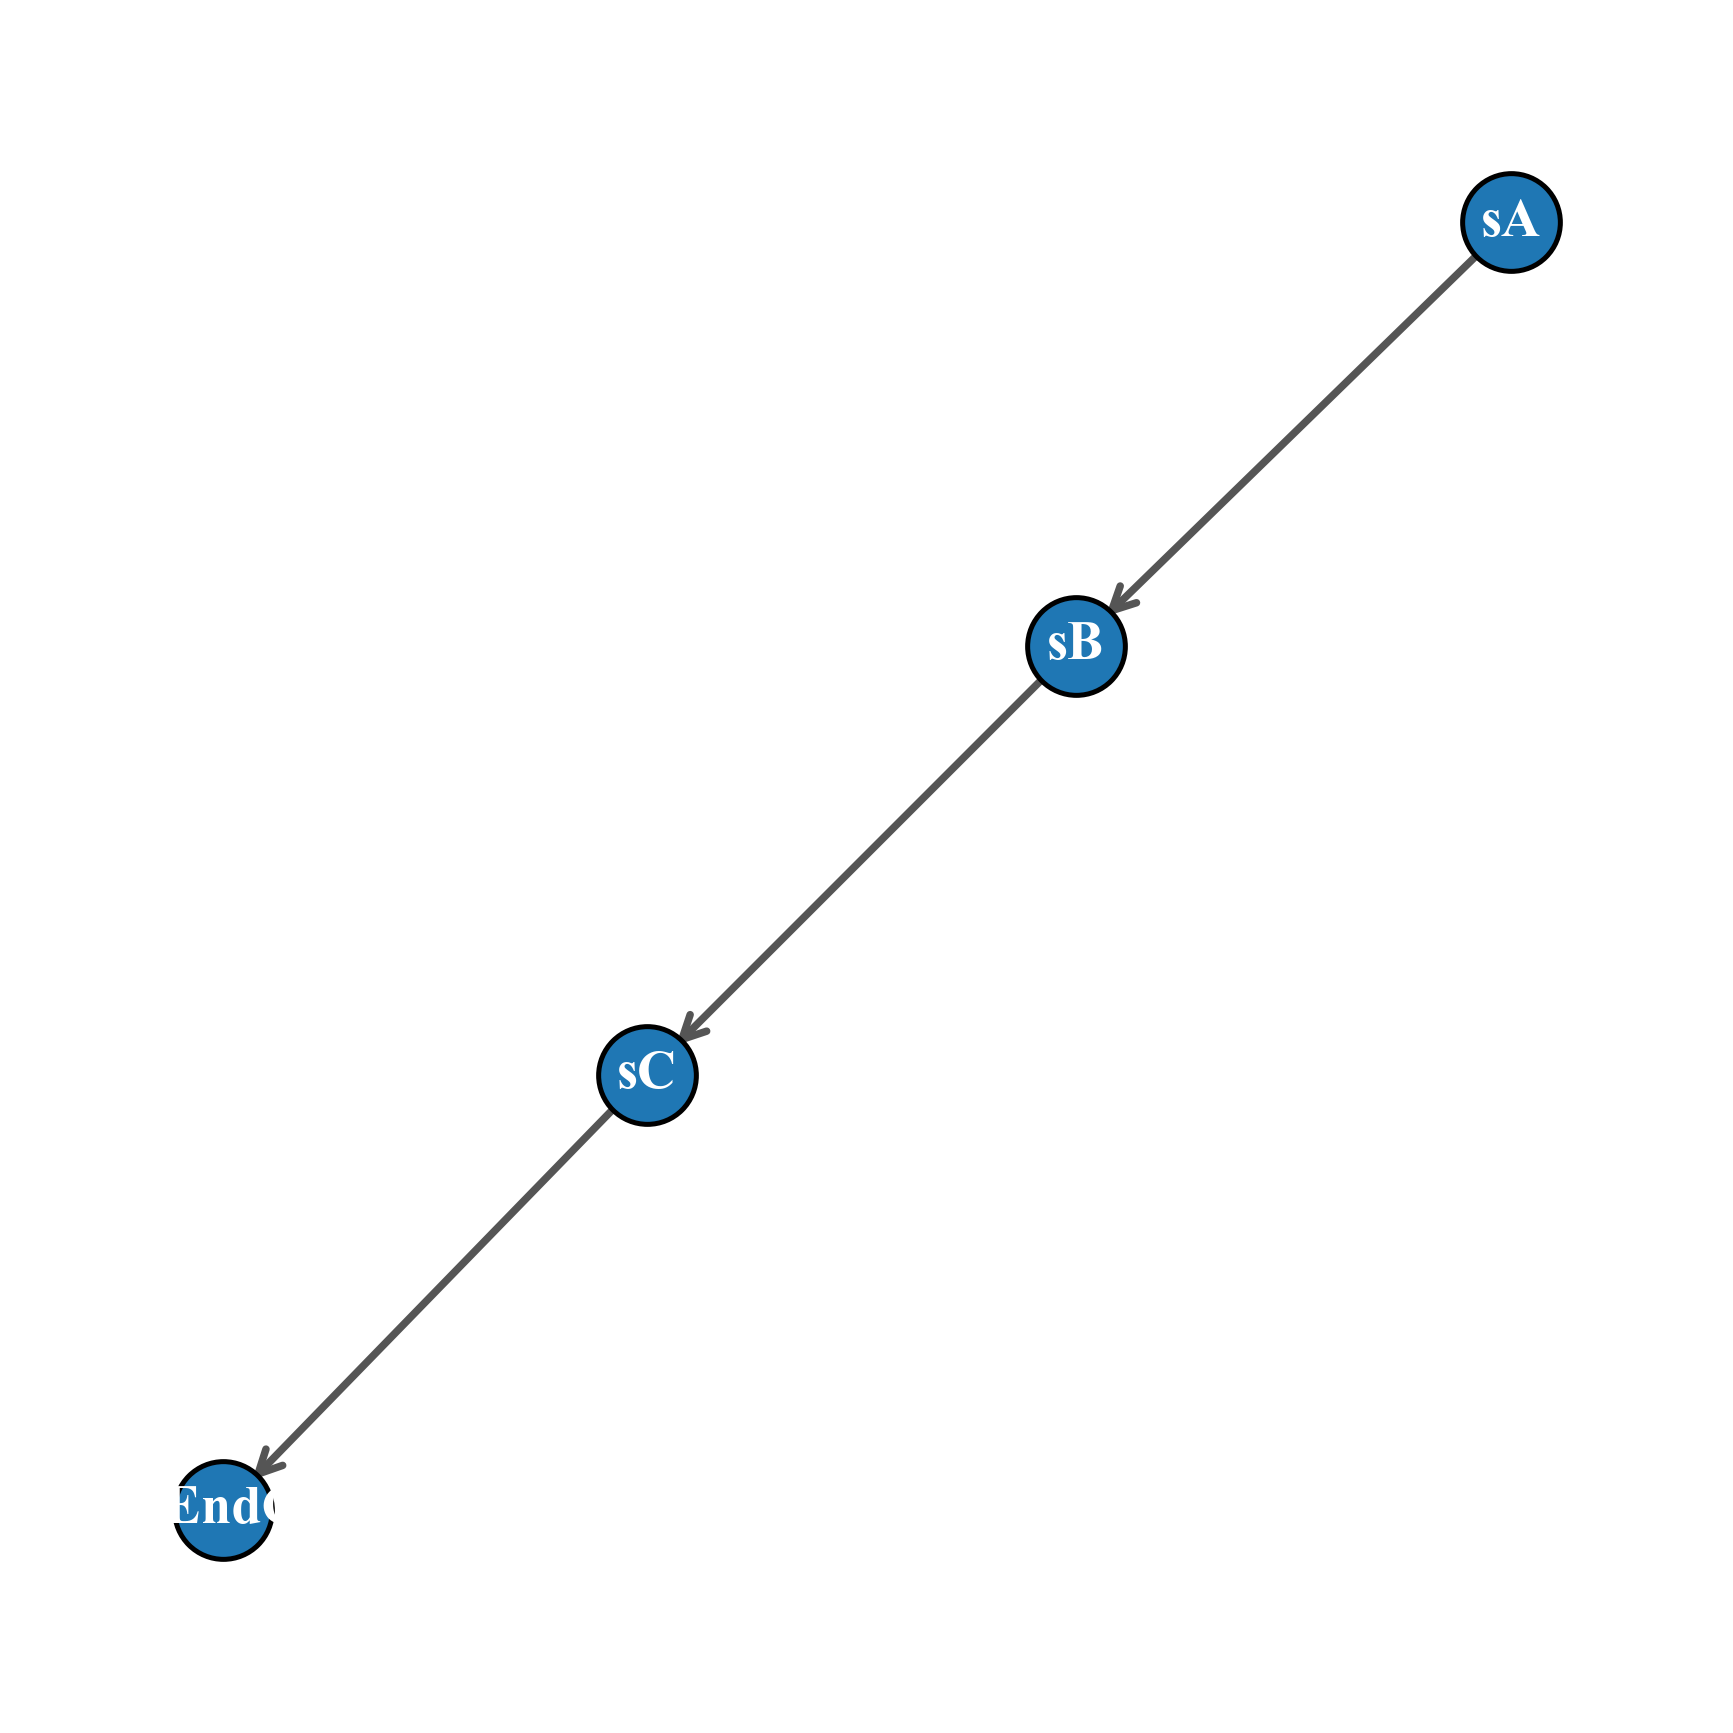

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def plot_milestone_network_auto(adata, 
                                figsize=(7, 6),
                                node_size=500,
                                font_size=12,
                                edge_color='#555555',
                                root_color='#d62728',      
                                other_color='#1f77b4',   
                                font_color='white'):

    if 'milestone_network' not in adata.uns:
        raise KeyError("adata.uns does not contain 'milestone_network', please run trajectory inference first.")
    
    net_df = adata.uns['milestone_network']
    if not {'from', 'to'}.issubset(net_df.columns):
        raise ValueError("milestone_network must contain 'from' and 'to' columns")

    G = nx.DiGraph()
    for _, row in net_df.iterrows():
        G.add_edge(row['from'], row['to'])

    pos_dict = nx.kamada_kawai_layout(G)
    milestone_positions = pd.DataFrame({
        node: (xy[0], xy[1]) for node, xy in pos_dict.items()
    }).T
    milestone_positions.columns = ['x', 'y']

    root = adata.uns.get('start_id', None)
    if root is None:
        out_degrees = dict(G.out_degree())
        root_candidates = [node for node, deg in out_degrees.items() if deg == 0]
        root = root_candidates[0] if root_candidates else list(G.nodes())[0]
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    ax.set_aspect('equal')
    
    for _, row in net_df.iterrows():
        start = milestone_positions.loc[row['from']].values
        end   = milestone_positions.loc[row['to']].values
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='->',
                                    color=edge_color,
                                    lw=1.8,
                                    shrinkA=10, shrinkB=10))
    
    for node in milestone_positions.index:
        x, y = milestone_positions.loc[node]
        color = root_color if node == root else other_color
        ax.scatter(x, y, 
                   color=color, 
                   s=node_size,
                   edgecolor='black',
                   linewidth=1.2,
                   zorder=5)
        ax.text(x, y, node,
                ha='center', va='center',
                color=font_color,
                fontsize=font_size,
                fontweight='bold',
                zorder=6)
    
    plt.margins(0.15)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_milestone_network_auto(adata_hvg, node_size=550, font_size=13)
plt.show()

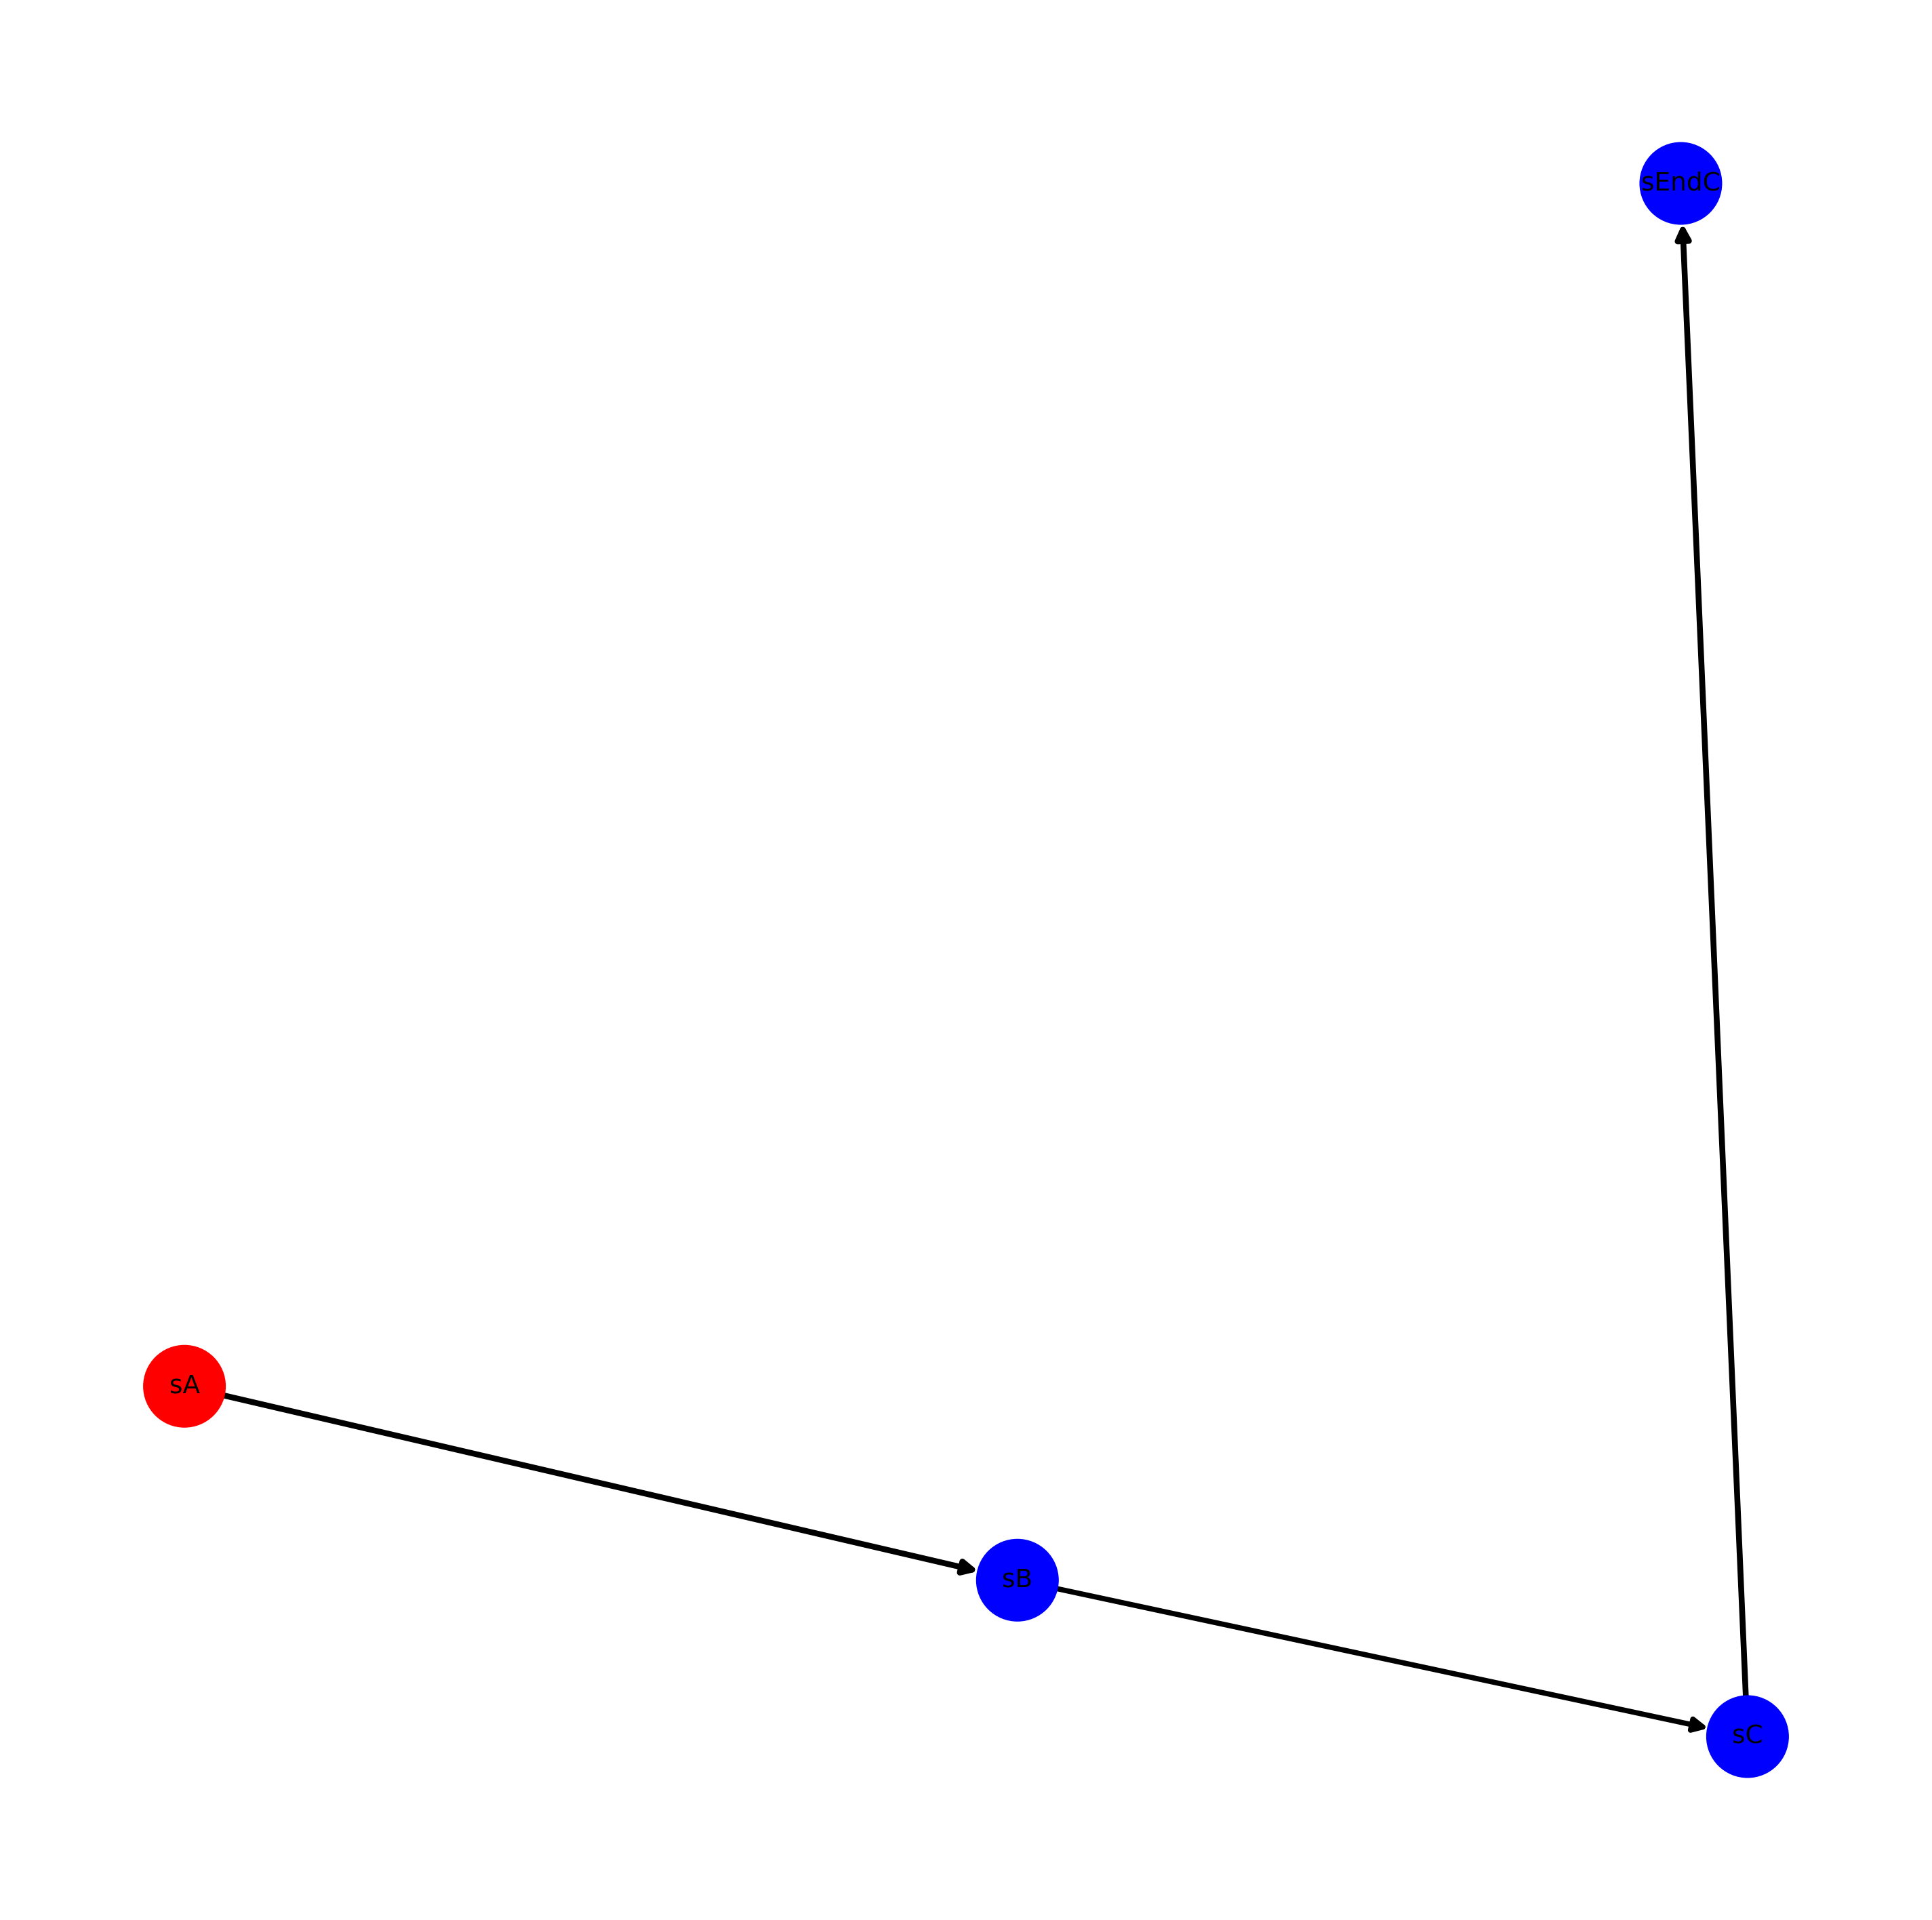

In [27]:
from util.Plot import plot_gt_milestone_network

plot_gt_milestone_network(adata_hvg)

In [28]:
from models.model_utils import DIPlot

从DI矩阵构建的连接矩阵:
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  1.0
3  0.0  0.0  0.0  0.0
4  1.0  0.0  0.0  0.0
非零连接数: 3


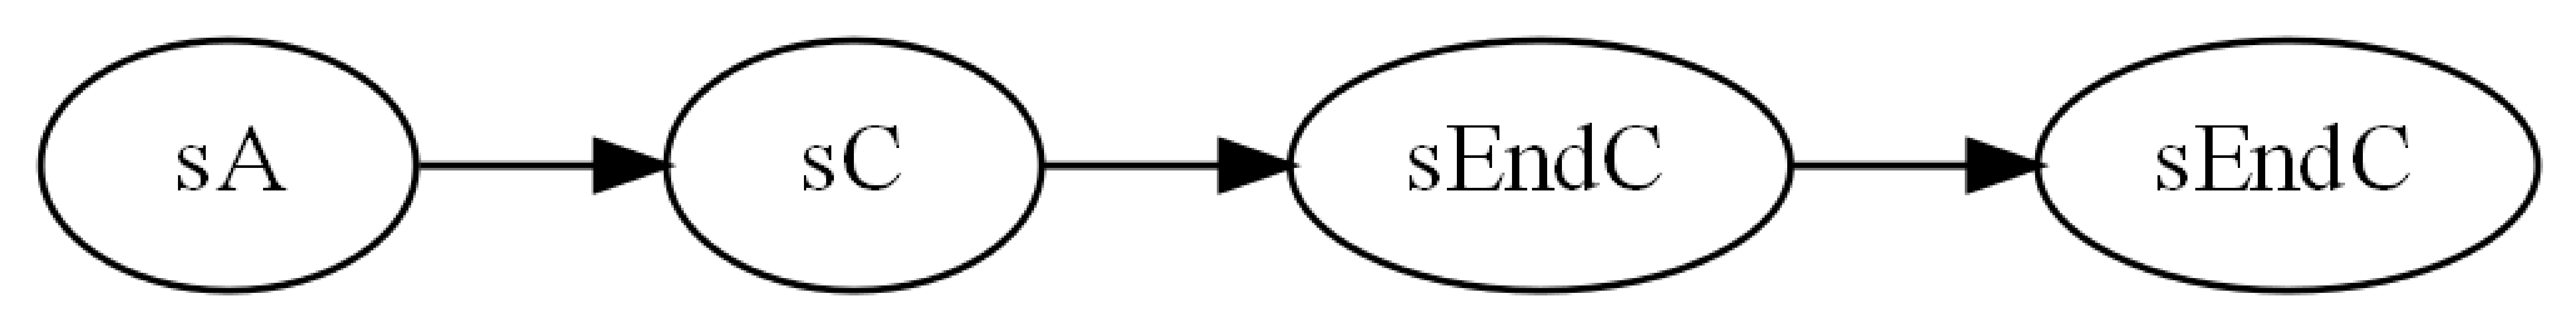

In [29]:
from models.model_utils import *

pseudo_key = 'cascat_pseudotime'
obj = DIPlot(adata_hvg
             , start_cell_idx=adata_hvg.uns['start_id'],
              root=adata_hvg.uns['root'], group_frac=adata_hvg.uns['group_frac'], save_path='./result',
              pseudo_key='cascat_pseudotime', di_key='cascat_directed_tree_conn', predict_key='cascat_clusters',
              emb_key='cascat_embedding')
obj.plot_trajectory_tree()

In [ ]:
def plot_embedding(self, show=True, colors='Paired', arrow_color='black', arrow_width=2):
    plot_embedding(self.emd, self.group_frac, self.connectivities, self.predict_labels,
                   colors=colors, save_path=self.img_path + 'emb.png',
                   label_map=self.labels_map, show=show,
                   arrow_color=arrow_color, arrow_width=arrow_width) 

实际聚类顺序: ['1', '4', '3', '2']
传入的连接矩阵内容:
     1    2    3    4
1  0.0  0.0  1.0  0.0
2  0.0  0.0  0.0  1.0
3  0.0  0.0  0.0  0.0
4  1.0  0.0  0.0  0.0
非零连接数: 3
图中的边: [('1', '3'), ('2', '4'), ('4', '1')]
图的节点: ['1', '2', '3', '4']


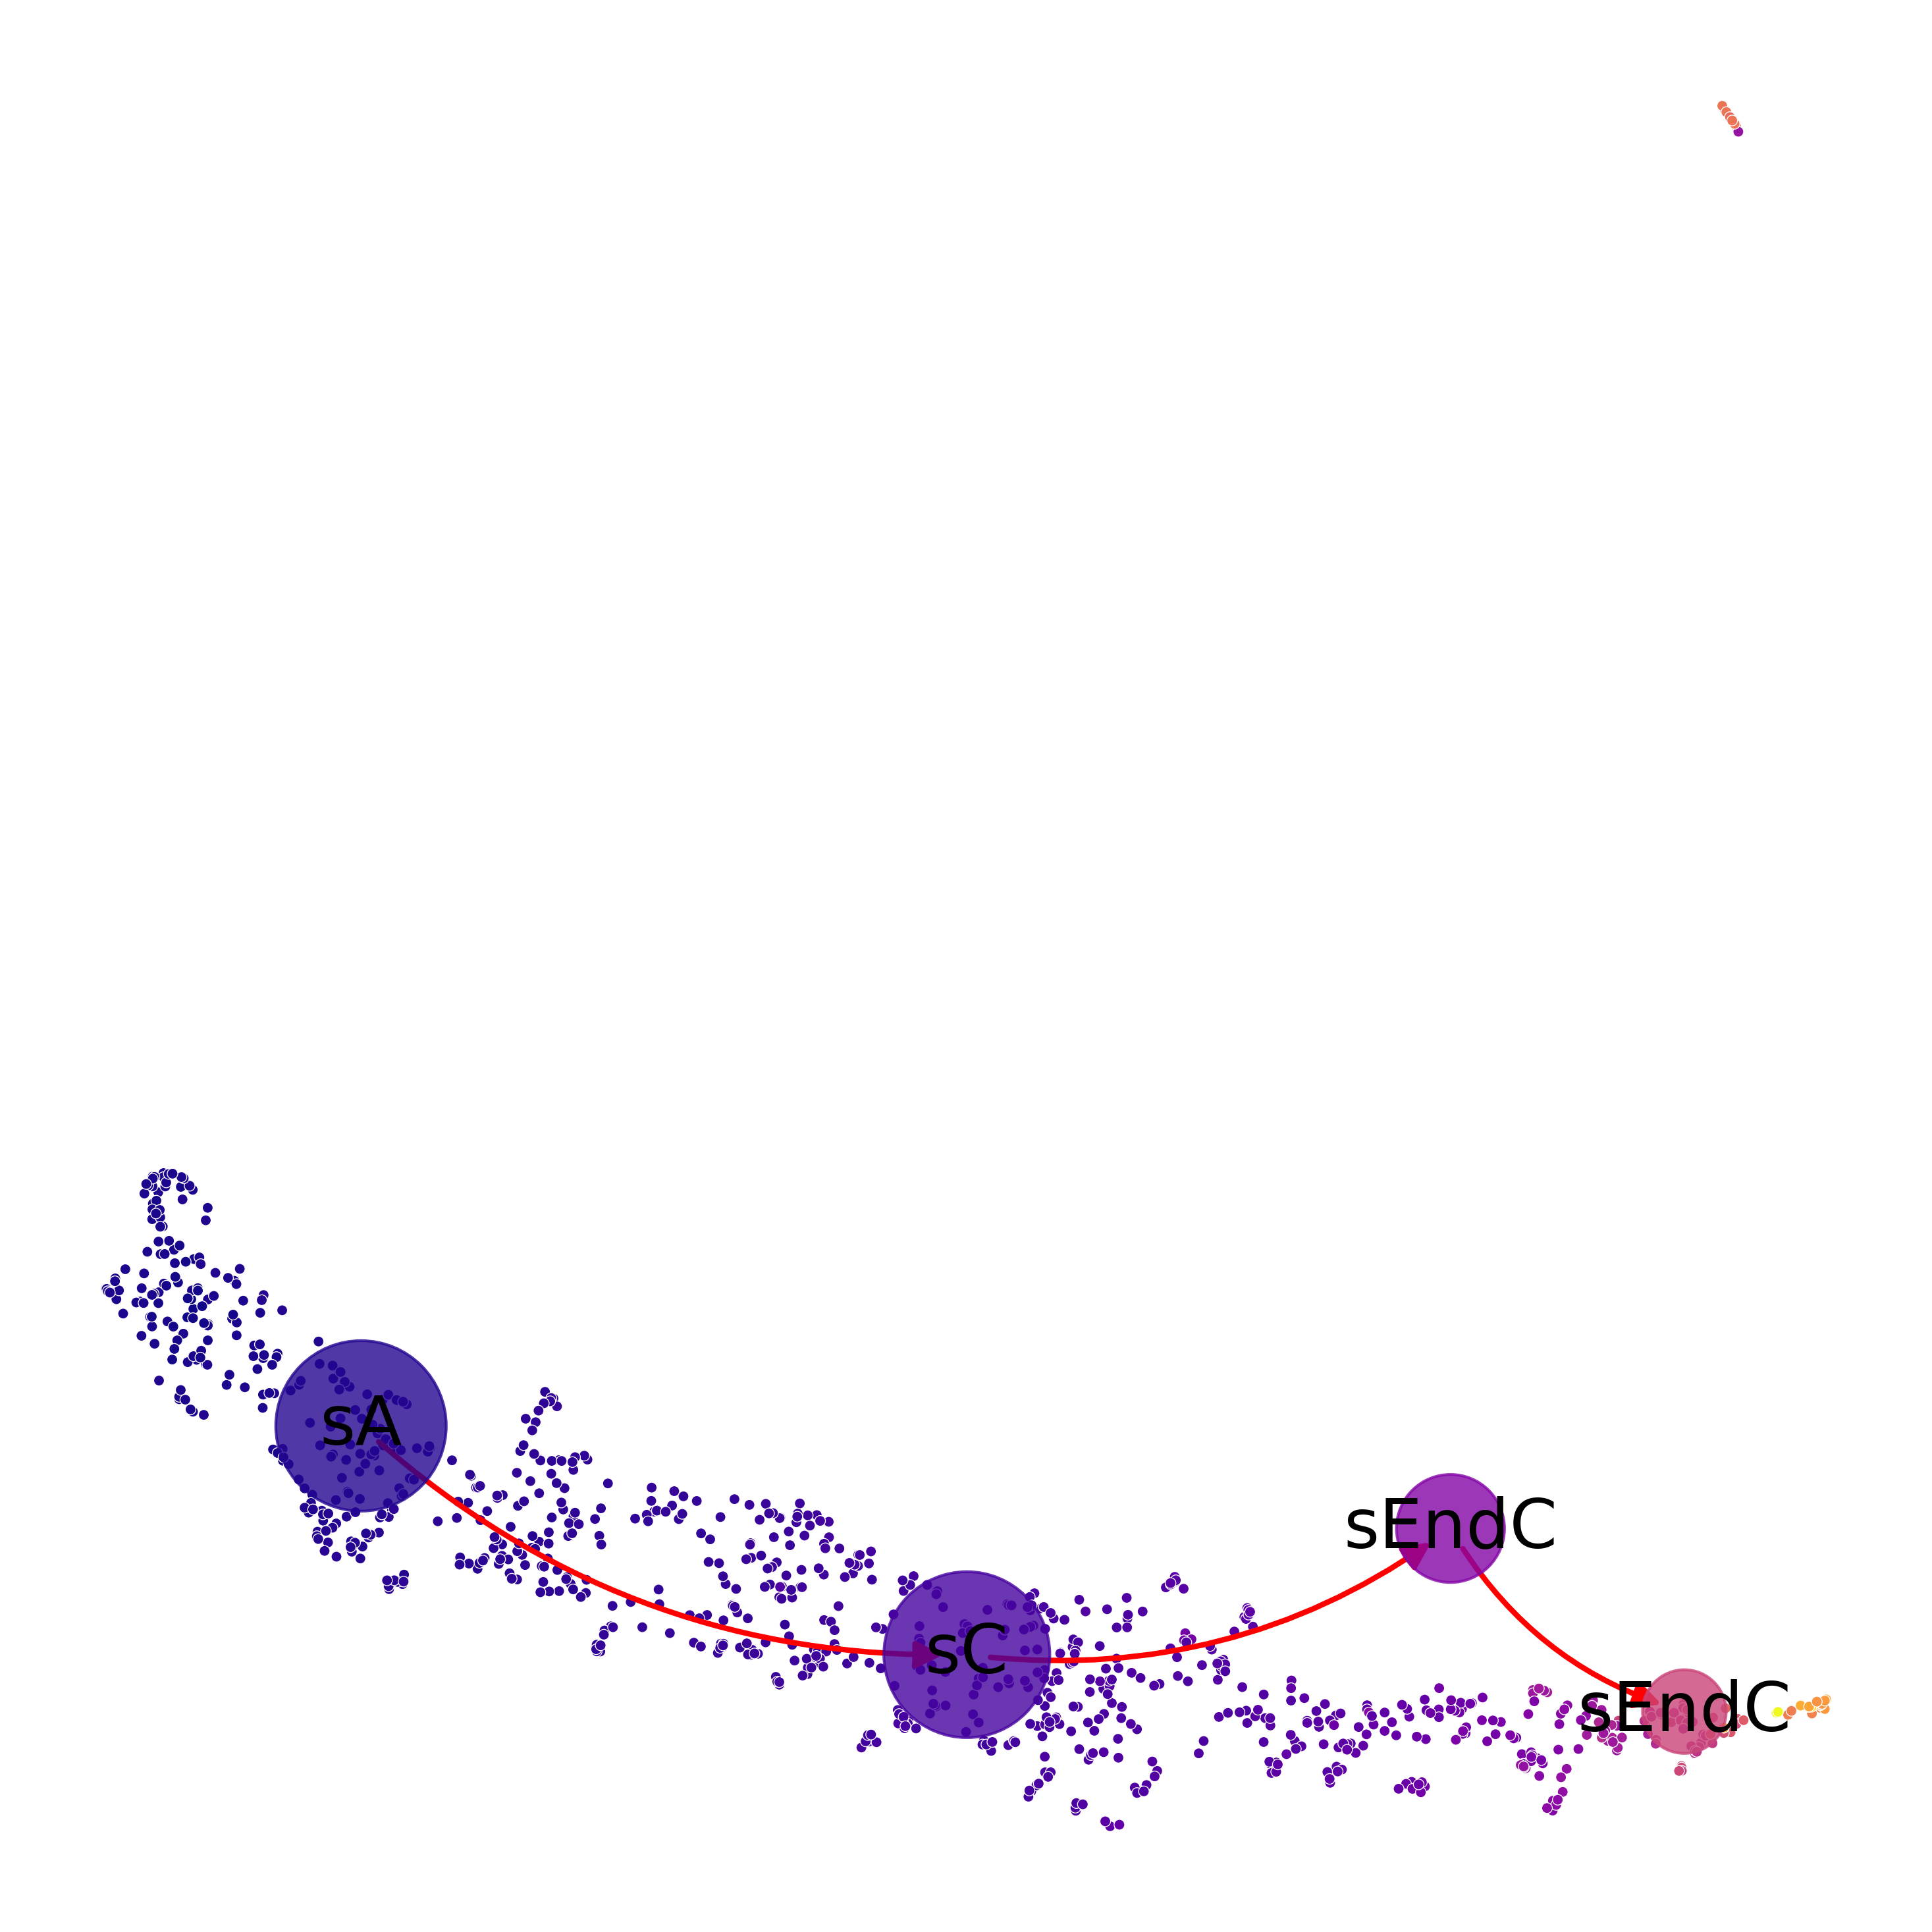

In [ ]:
obj.plot_pseudotime()